Hamming(31,26) 符号シミュレータ
符号               : Hamming(31,26): n=31, k=26, parity=5
パリティ位置       : [1, 2, 4, 8, 16]
データビット       : 10011101000001101011111011
送信符号語         : 1111001011010000001101011111011
誤り位置           : 26
受信語             : 1111001011010000001101011011011
シンドローム       : [0, 1, 0, 1, 1]
シンドローム値     : 26
訂正後             : 1111001011010000001101011111011


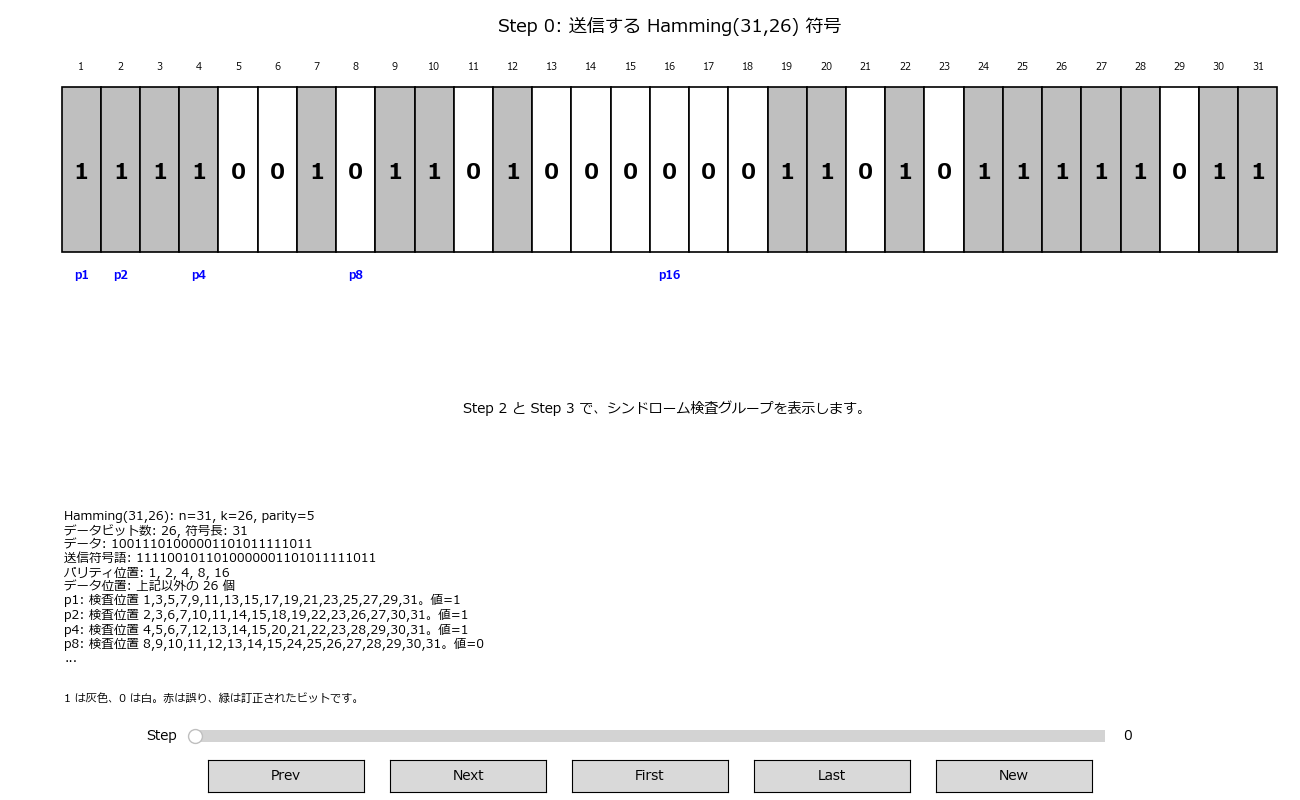

In [6]:
import random
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.widgets import Button, Slider

%matplotlib widget

matplotlib.rcParams["font.family"] = "Meiryo"
matplotlib.rcParams["axes.unicode_minus"] = False

player = None

R = 5
N = 2 ** R - 1
K = N - R

TITLE_TEXT = "Hamming(31,26): n=31, k=26, parity=5"


def bits_to_str(bits):
    return "".join(str(b) for b in bits)


def xor_sum(values):
    result = 0
    for v in values:
        result ^= v
    return result


def is_power_of_two(x):
    return x > 0 and (x & (x - 1)) == 0


class Hamming3126:
    def __init__(self, data_bits=None, error_pos=None):
        if data_bits is None:
            data_bits = [random.randint(0, 1) for _ in range(K)]

        self.data_bits = data_bits[:]
        self.parity_positions = [1, 2, 4, 8, 16]

        self.codeword = self.encode(self.data_bits)

        if error_pos is None:
            error_pos = random.randint(1, N)

        self.error_pos = error_pos

        self.received = self.codeword[:]
        self.before_error_bit = self.received[self.error_pos - 1]
        self.received[self.error_pos - 1] ^= 1
        self.after_error_bit = self.received[self.error_pos - 1]

        self.syndrome_bits, self.syndrome_value = self.calc_syndrome(self.received)

        self.corrected = self.received[:]
        self.before_correct_bit = self.corrected[self.syndrome_value - 1]
        self.corrected[self.syndrome_value - 1] ^= 1
        self.after_correct_bit = self.corrected[self.syndrome_value - 1]

    def encode(self, data):
        code = [0] * N
        data_index = 0

        for pos in range(1, N + 1):
            if not is_power_of_two(pos):
                code[pos - 1] = data[data_index]
                data_index += 1

        self.parity_values = {}

        for p in self.parity_positions:
            group = [pos for pos in range(1, N + 1) if pos & p]
            values = [code[pos - 1] for pos in group if pos != p]
            parity = xor_sum(values)
            code[p - 1] = parity
            self.parity_values[p] = parity

        return code

    def calc_syndrome(self, bits):
        syndrome_bits = []
        syndrome_value = 0

        for p in self.parity_positions:
            group = [pos for pos in range(1, N + 1) if pos & p]
            value = xor_sum([bits[pos - 1] for pos in group])
            syndrome_bits.append(value)
            syndrome_value += value * p

        return syndrome_bits, syndrome_value

    def parity_explanation(self):
        lines = [
            "パリティ位置: 1, 2, 4, 8, 16",
            "データ位置: 上記以外の 26 個"
        ]

        for p in self.parity_positions:
            group = [pos for pos in range(1, N + 1) if pos & p]
            group_str = ",".join(str(x) for x in group)
            lines.append(f"p{p}: 検査位置 {group_str}。値={self.parity_values[p]}")

        return "\n".join(lines)

    def syndrome_explanation(self):
        lines = []

        for i, p in enumerate(self.parity_positions):
            group = [pos for pos in range(1, N + 1) if pos & p]
            group_str = ",".join(str(x) for x in group)
            lines.append(f"s{p}: 位置 {group_str} の xor = {self.syndrome_bits[i]}")

        s1, s2, s4, s8, s16 = self.syndrome_bits

        lines.append("")
        lines.append(f"誤り位置 = {s1}*1 + {s2}*2 + {s4}*4 + {s8}*8 + {s16}*16")
        lines.append(f"        = {self.syndrome_value}")

        return "\n".join(lines)


def draw_bit_cells(ax, bits, title, highlight_pos=None, corrected_pos=None):
    ax.clear()

    cell_w = 0.82
    cell_h = 1.05

    for i, bit in enumerate(bits):
        pos = i + 1
        x = i * cell_w
        y = 0

        face = "#BFBFBF" if bit == 1 else "white"

        if highlight_pos == pos:
            face = "#FFCCCC"

        if corrected_pos == pos:
            face = "#CCFFCC"

        rect = Rectangle(
            (x, y),
            cell_w,
            cell_h,
            facecolor=face,
            edgecolor="black",
            linewidth=1.2
        )
        ax.add_patch(rect)

        ax.text(
            x + cell_w / 2,
            y + 1.18,
            str(pos),
            ha="center",
            va="center",
            fontsize=7
        )

        ax.text(
            x + cell_w / 2,
            y + 0.50,
            str(bit),
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold"
        )

        if is_power_of_two(pos):
            ax.text(
                x + cell_w / 2,
                y - 0.15,
                f"p{pos}",
                ha="center",
                va="center",
                fontsize=8,
                color="blue",
                fontweight="bold"
            )

    ax.set_xlim(-0.2, N * cell_w + 0.2)
    ax.set_ylim(-0.35, 1.35)
    ax.axis("off")
    ax.set_title(title, fontsize=13, pad=6)


def draw_syndrome_groups(ax, syndrome_groups=None):
    ax.clear()

    cell_w = 0.82
    ax.set_xlim(-0.5, N * cell_w + 0.6)
    ax.set_ylim(-0.3, 5.2)
    ax.axis("off")

    if syndrome_groups is None:
        ax.text(
            N * cell_w / 2,
            2.4,
            "Step 2 と Step 3 で、シンドローム検査グループを表示します。",
            ha="center",
            va="center",
            fontsize=10
        )
        return

    colors = ["green", "orange", "blue", "purple", "brown"]

    for row, (name, group) in enumerate(syndrome_groups):
        y = 4.6 - row

        ax.text(
            -0.12,
            y,
            name,
            ha="right",
            va="center",
            fontsize=10,
            color=colors[row]
        )

        for pos in range(1, N + 1):
            x = (pos - 1) * cell_w + cell_w / 2

            if pos in group:
                ax.scatter(x, y, s=36, color=colors[row])
            else:
                ax.scatter(x, y, s=8, color="lightgray")

    ax.set_title("シンドローム検査グループ", fontsize=11, pad=2)


def draw_explanation(ax, explanation):
    ax.clear()
    ax.axis("off")

    lines = explanation.split("\n")
    max_lines = 10

    if len(lines) > max_lines:
        lines = lines[:max_lines] + ["..."]

    short_text = "\n".join(lines)

    ax.text(
        0.01,
        0.98,
        short_text,
        ha="left",
        va="top",
        fontsize=9,
        linespacing=1.15,
        transform=ax.transAxes
    )

    ax.text(
        0.01,
        0.00,
        "1 は灰色、0 は白。赤は誤り、緑は訂正されたビットです。",
        ha="left",
        va="bottom",
        fontsize=8,
        transform=ax.transAxes
    )


class HammingPlayer:
    def __init__(self, hamming):
        self.h = hamming
        self.index = 0
        self.steps = self.make_steps()

        self.fig = plt.figure(figsize=(13, 8))

        gs = self.fig.add_gridspec(
            3,
            1,
            height_ratios=[2.3, 1.3, 1.7]
        )

        self.ax_bits = self.fig.add_subplot(gs[0])
        self.ax_groups = self.fig.add_subplot(gs[1])
        self.ax_text = self.fig.add_subplot(gs[2])

        plt.subplots_adjust(
            left=0.04,
            right=0.99,
            top=0.95,
            bottom=0.12,
            hspace=0.12
        )

        ax_slider = plt.axes([0.15, 0.065, 0.70, 0.030])

        ax_prev = plt.axes([0.16, 0.010, 0.12, 0.040])
        ax_next = plt.axes([0.30, 0.010, 0.12, 0.040])
        ax_first = plt.axes([0.44, 0.010, 0.12, 0.040])
        ax_last = plt.axes([0.58, 0.010, 0.12, 0.040])
        ax_new = plt.axes([0.72, 0.010, 0.12, 0.040])

        self.btn_prev = Button(ax_prev, "Prev")
        self.btn_next = Button(ax_next, "Next")
        self.btn_first = Button(ax_first, "First")
        self.btn_last = Button(ax_last, "Last")
        self.btn_new = Button(ax_new, "New")

        self.btn_prev.on_clicked(self.on_prev)
        self.btn_next.on_clicked(self.on_next)
        self.btn_first.on_clicked(self.on_first)
        self.btn_last.on_clicked(self.on_last)
        self.btn_new.on_clicked(self.on_new)

        self.slider = Slider(
            ax_slider,
            "Step",
            0,
            len(self.steps) - 1,
            valinit=0,
            valstep=1
        )
        self.slider.on_changed(self.on_slider)

        self.draw()

    def make_steps(self):
        h = self.h

        groups = []
        for p in h.parity_positions:
            group = [pos for pos in range(1, N + 1) if pos & p]
            groups.append((f"s{p}", group))

        return [
            {
                "bits": h.codeword,
                "title": "Step 0: 送信する Hamming(31,26) 符号",
                "highlight_pos": None,
                "corrected_pos": None,
                "syndrome_groups": None,
                "explanation": (
                    f"{TITLE_TEXT}\n"
                    f"データビット数: {K}, 符号長: {N}\n"
                    f"データ: {bits_to_str(h.data_bits)}\n"
                    f"送信符号語: {bits_to_str(h.codeword)}\n"
                    f"{h.parity_explanation()}"
                )
            },
            {
                "bits": h.received,
                "title": "Step 1: 1ビット誤りが発生",
                "highlight_pos": h.error_pos,
                "corrected_pos": None,
                "syndrome_groups": None,
                "explanation": (
                    f"{h.error_pos} 番目のビットが反転しました。\n"
                    f"反転前: {h.before_error_bit} → 反転後: {h.after_error_bit}\n"
                    f"送信符号語: {bits_to_str(h.codeword)}\n"
                    f"受信語:     {bits_to_str(h.received)}"
                )
            },
            {
                "bits": h.received,
                "title": "Step 2: シンドロームを計算",
                "highlight_pos": h.error_pos,
                "corrected_pos": None,
                "syndrome_groups": groups,
                "explanation": h.syndrome_explanation()
            },
            {
                "bits": h.received,
                "title": "Step 3: 誤り位置を特定",
                "highlight_pos": h.syndrome_value,
                "corrected_pos": None,
                "syndrome_groups": groups,
                "explanation": (
                    f"シンドローム bits = {h.syndrome_bits}\n"
                    f"重み付き和 = {h.syndrome_value}\n"
                    f"したがって、{h.syndrome_value} 番目のビットが誤りです。"
                )
            },
            {
                "bits": h.corrected,
                "title": "Step 4: 誤りを訂正",
                "highlight_pos": None,
                "corrected_pos": h.syndrome_value,
                "syndrome_groups": None,
                "explanation": (
                    f"{h.syndrome_value} 番目を反転して訂正します。\n"
                    f"訂正前: {h.before_correct_bit} → 訂正後: {h.after_correct_bit}\n"
                    f"受信語:     {bits_to_str(h.received)}\n"
                    f"訂正後:     {bits_to_str(h.corrected)}\n"
                    f"元の符号語: {bits_to_str(h.codeword)}"
                )
            },
        ]

    def draw(self):
        step = self.steps[self.index]

        draw_bit_cells(
            self.ax_bits,
            bits=step["bits"],
            title=step["title"],
            highlight_pos=step["highlight_pos"],
            corrected_pos=step["corrected_pos"]
        )

        draw_syndrome_groups(
            self.ax_groups,
            syndrome_groups=step["syndrome_groups"]
        )

        draw_explanation(
            self.ax_text,
            step["explanation"]
        )

        self.fig.canvas.draw_idle()

    def set_index(self, idx):
        self.index = max(0, min(int(idx), len(self.steps) - 1))

        self.slider.eventson = False
        self.slider.set_val(self.index)
        self.slider.eventson = True

        self.draw()

    def on_prev(self, event):
        self.set_index(self.index - 1)

    def on_next(self, event):
        self.set_index(self.index + 1)

    def on_first(self, event):
        self.set_index(0)

    def on_last(self, event):
        self.set_index(len(self.steps) - 1)

    def on_new(self, event):
        self.h = Hamming3126()
        self.steps = self.make_steps()
        self.set_index(0)
        self.print_summary("新しい Hamming(31,26) 符号")

    def on_slider(self, value):
        self.set_index(int(value))

    def print_summary(self, header):
        print("\n" + "=" * 70)
        print(header)
        print("=" * 70)
        print("符号               :", TITLE_TEXT)
        print("データビット       :", bits_to_str(self.h.data_bits))
        print("送信符号語         :", bits_to_str(self.h.codeword))
        print("誤り位置           :", self.h.error_pos)
        print("受信語             :", bits_to_str(self.h.received))
        print("シンドローム       :", self.h.syndrome_bits)
        print("シンドローム値     :", self.h.syndrome_value)
        print("訂正後             :", bits_to_str(self.h.corrected))


def main():
    global player

    h = Hamming3126()

    print("=" * 70)
    print("Hamming(31,26) 符号シミュレータ")
    print("=" * 70)
    print("符号               :", TITLE_TEXT)
    print("パリティ位置       :", h.parity_positions)
    print("データビット       :", bits_to_str(h.data_bits))
    print("送信符号語         :", bits_to_str(h.codeword))
    print("誤り位置           :", h.error_pos)
    print("受信語             :", bits_to_str(h.received))
    print("シンドローム       :", h.syndrome_bits)
    print("シンドローム値     :", h.syndrome_value)
    print("訂正後             :", bits_to_str(h.corrected))

    player = HammingPlayer(h)
    plt.show()


if __name__ == "__main__":
    main()